# Student Performance Prediction Using Machine Learning

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor , GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

import joblib
import os

## 2. Load Dataset

In [2]:
df = pd.read_csv('../data/student-mat.csv', sep=';')
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


## 3. Data Understanding

In [3]:
print("Shape:", df.shape)

Shape: (395, 33)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [5]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [6]:
df.corr(numeric_only = True)["G3"].sort_values(ascending=False)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

## 4. Cleaning Data

In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [8]:
print("Duplicates:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicates: 0


## 5. Encoding

In [9]:
binary_map = {"yes":1, "no":0}

binary_cols = [
    "schoolsup","famsup","paid","activities",
    "higher","internet","romantic"
]

for col in binary_cols:
    df[col] = df[col].map(binary_map)

## 6. Encode Categorical Variables

In [10]:
df["sex"] = df["sex"].map({"M":1, "F":0})
df["school"] = df["school"].map({"GP":1, "MS":0})
df["address"] = df["address"].map({"U":1, "R":0})
df["famsize"] = df["famsize"].map({"GT3":1, "LE3":0})
df["Pstatus"] = df["Pstatus"].map({"T":1, "A":0})

In [11]:
df = pd.get_dummies(df, drop_first=True)
df = df.astype(int)

In [12]:
df.head(20)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,nursery_yes
0,1,0,18,1,1,0,4,4,2,2,...,0,0,0,1,0,0,0,1,0,1
1,1,0,17,1,1,1,1,1,1,2,...,0,1,0,0,0,0,0,0,0,0
2,1,0,15,1,0,1,1,1,1,2,...,0,1,0,0,0,1,0,1,0,1
3,1,0,15,1,1,1,4,2,1,3,...,0,0,1,0,1,0,0,1,0,1
4,1,0,16,1,1,1,3,3,1,2,...,0,1,0,0,1,0,0,0,0,1
5,1,1,16,1,0,1,4,3,1,2,...,0,1,0,0,0,0,1,1,0,1
6,1,1,16,1,0,1,2,2,1,2,...,0,1,0,0,1,0,0,1,0,1
7,1,0,17,1,1,0,4,4,2,2,...,0,0,0,1,1,0,0,1,0,1
8,1,1,15,1,0,0,3,2,1,2,...,0,1,0,0,1,0,0,1,0,1
9,1,1,15,1,1,1,3,4,1,2,...,0,1,0,0,1,0,0,1,0,1


In [13]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid',
       'activities', 'higher', 'internet', 'romantic', 'famrel', 'freetime',
       'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3',
       'Mjob_health', 'Mjob_other', 'Mjob_services', 'Mjob_teacher',
       'Fjob_health', 'Fjob_other', 'Fjob_services', 'Fjob_teacher',
       'reason_home', 'reason_other', 'reason_reputation', 'guardian_mother',
       'guardian_other', 'nursery_yes'],
      dtype='object')

## 7. Exploratory Data Analysis

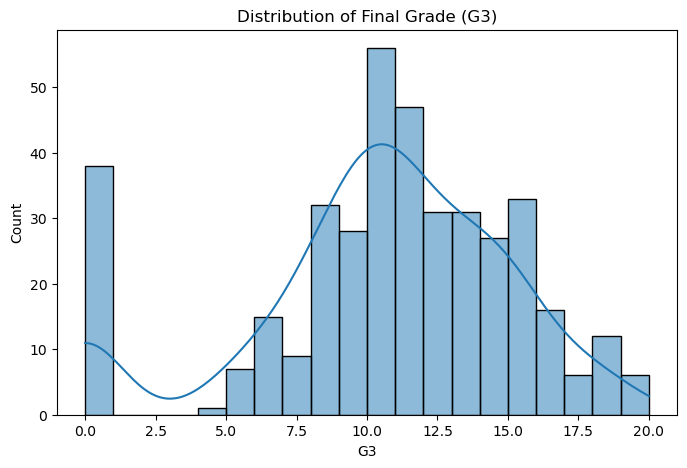

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=20, kde=True)
plt.title("Distribution of Final Grade (G3)")
plt.show()

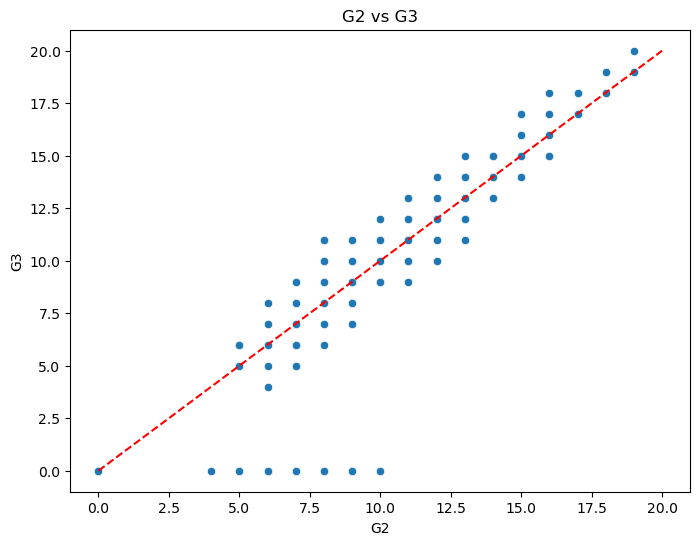

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='G2', y='G3', data=df)
plt.plot([0,20], [0,20], 'r--')
plt.title("G2 vs G3")
plt.show()

## 9. Correlation with Target

In [16]:
corr = df.corr(numeric_only=True)["G3"].sort_values(ascending=False)

corr.head(15)

G3                   1.000000
G2                   0.904868
G1                   0.801468
Medu                 0.217147
higher               0.182465
Fedu                 0.152457
Mjob_health          0.116158
address              0.105756
sex                  0.103456
paid                 0.101996
internet             0.098483
studytime            0.097820
reason_reputation    0.095692
Fjob_teacher         0.095374
Mjob_services        0.078429
Name: G3, dtype: float64

## 10. Feature Selection - MODEL A

In [17]:
y=df["G3"]
x = df.drop("G3", axis=1)

## 11. Train Test Split - MODEL A

In [18]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
x_train.shape , x_test.shape

((316, 41), (79, 41))

## 12. Evaluation Function - MODEL A

In [20]:
def evaluate_model(name, model, x_train, x_test, y_train, y_test):
    
    model.fit(x_train, y_train)
    pred = model.predict(x_test)
    
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    
    return {
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3)
    }

## 13. Train Multiple Models - MODEL A

In [21]:
models = [
    ("Linear Regression", LinearRegression()),
    ("Lasso", Lasso(alpha=0.01)),
    ("Decision Tree", DecisionTreeRegressor(max_depth=5, random_state=42)),
    ("Random Forest", RandomForestRegressor(random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(random_state=42))
]

## 14. Results Table - MODEL A

In [22]:
results = []

for name, model in models:
    results.append(
        evaluate_model(name, model, x_train, x_test, y_train, y_test)
    )

results_df = pd.DataFrame(results)
results_df.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
3,Random Forest,1.155,1.951,0.814
4,Gradient Boosting,1.166,2.008,0.803
1,Lasso,1.580,2.318,0.738
0,Linear Regression,1.647,2.378,0.724
2,Decision Tree,1.468,2.655,0.656


## 15. Final Random Forest Visualizations - MODEL A

In [23]:
model_A = RandomForestRegressor(random_state=42)
model_A.fit(x_train, y_train)

pred1 = model_A.predict(x_test)

print("Model A R2:", r2_score(y_test, pred1))

Model A R2: 0.8143999413934299


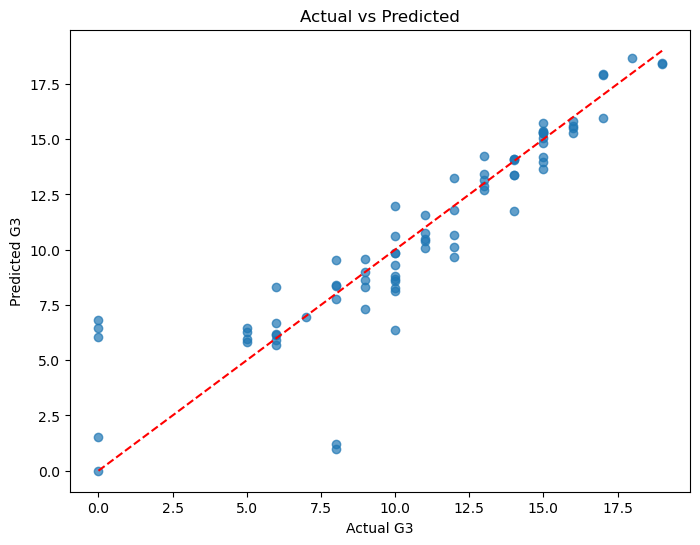

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred1, alpha=0.7)

min_val = min(min(y_test), min(pred1))
max_val = max(max(y_test), max(pred1))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--"
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Actual vs Predicted")
plt.show()

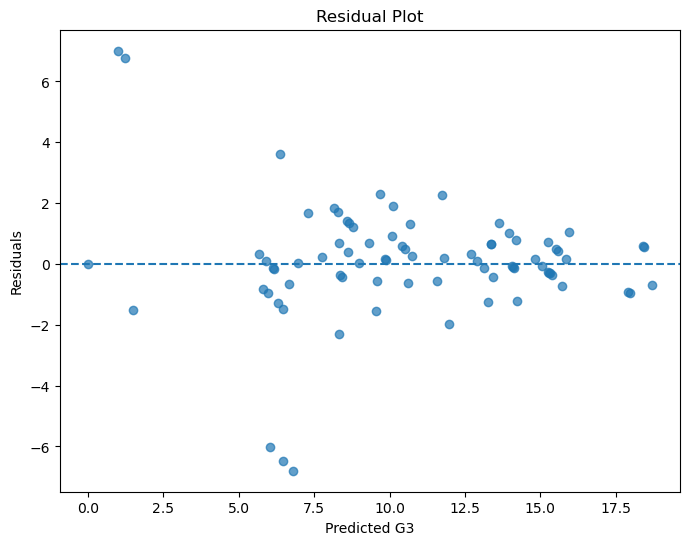

In [25]:
residuals = y_test - pred1
plt.figure(figsize=(8,6))
plt.scatter(pred1, residuals, alpha=0.7)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted G3")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

## 16. Feature Importance - MODEL A


Top 15 Important Features:
G2                 0.792979
absences           0.109950
reason_home        0.020925
age                0.010278
G1                 0.006522
famrel             0.005574
health             0.004333
activities         0.004196
goout              0.004187
studytime          0.003989
romantic           0.003417
Walc               0.003075
guardian_mother    0.002453
schoolsup          0.002149
Fedu               0.001949
dtype: float64


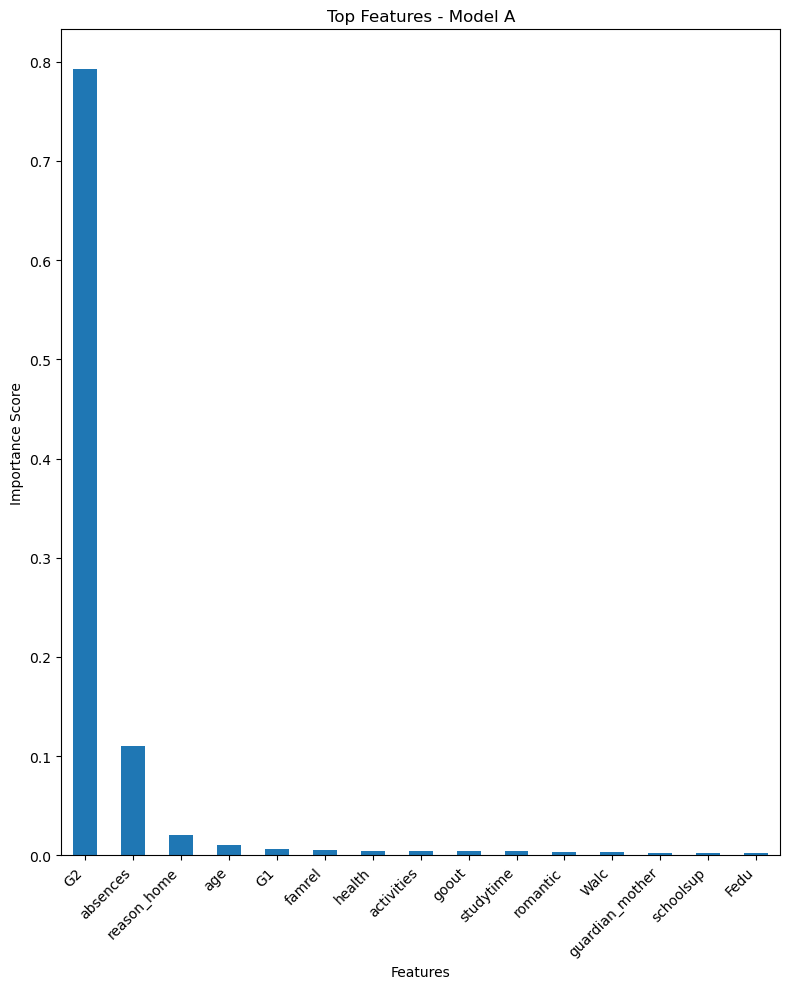

In [26]:
importance = pd.Series(model_A.feature_importances_,index=x_train.columns).sort_values(ascending=False)

print("\nTop 15 Important Features:")
print(importance.head(15))

plt.figure(figsize=(8,10))

importance.head(15).plot(kind="bar")

plt.title("Top Features - Model A")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 17. Cross Validation - MODEL A

In [27]:
scores = cross_val_score(model_A, x, y, cv=5, scoring='r2')
print("CV Scores:", scores)
print("Average R2:", scores.mean())

CV Scores: [0.77805745 0.8218944  0.86724488 0.87586006 0.82779899]
Average R2: 0.8341711549557024


## 18. Save Model - MODEL A

In [28]:
os.makedirs("../model", exist_ok=True)
joblib.dump(model_A, "../model/model_A_final_grade.pkl")

['../model/model_A_final_grade.pkl']

## 19. Feature Selection - MODEL B

In [29]:
x2 = df.drop(columns=["G1","G2","G3"])
y2 = df["G3"]

## 20. Train Test Split - MODEL B

In [30]:
x2_train, x2_test, y2_train, y2_test = train_test_split(x2, y2, test_size=0.2, random_state=42)

In [31]:
x2_train.shape , x2_test.shape

((316, 39), (79, 39))

## 21. Evaluation Function - MODEL B

In [32]:
def evaluate_modelB(name, model, x2_train, x2_test, y1_train, y2_test):
    
    model.fit(x2_train, y2_train)
    pred2 = model.predict(x2_test)
    
    mae = mean_absolute_error(y2_test, pred2)
    rmse = mean_squared_error(y2_test, pred2) ** 0.5
    r2 = r2_score(y2_test, pred2)
    
    return {
        "Model": name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "R2": round(r2, 3)
    }

## 22. Train Multiple Models - MODEL B

In [33]:
models = [
    ("Linear Regression", LinearRegression()),
    ("Lasso", Lasso(alpha=0.01)),
    ("Decision Tree", DecisionTreeRegressor(max_depth=5, random_state=42)),
    ("Random Forest", RandomForestRegressor(random_state=42)),
    ("Gradient Boosting", GradientBoostingRegressor(random_state=42))
]

In [34]:
results = []

for name, model in models:
    results.append(
        evaluate_modelB(name, model, x2_train, x2_test, y2_train, y2_test)
    )

results_df = pd.DataFrame(results)
results_df.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
3,Random Forest,3.140,3.912,0.254
4,Gradient Boosting,3.249,4.035,0.206
1,Lasso,3.382,4.192,0.143
0,Linear Regression,3.395,4.196,0.141
2,Decision Tree,3.431,4.482,0.020


## 23. Final Random Forest Visualizations - MODEL B

In [35]:
model_B = RandomForestRegressor(random_state=42)
model_B.fit(x2_train, y2_train)

pred3 = model_B.predict(x2_test)

print("Model B R2:", r2_score(y2_test, pred3))

Model B R2: 0.25372069593348545


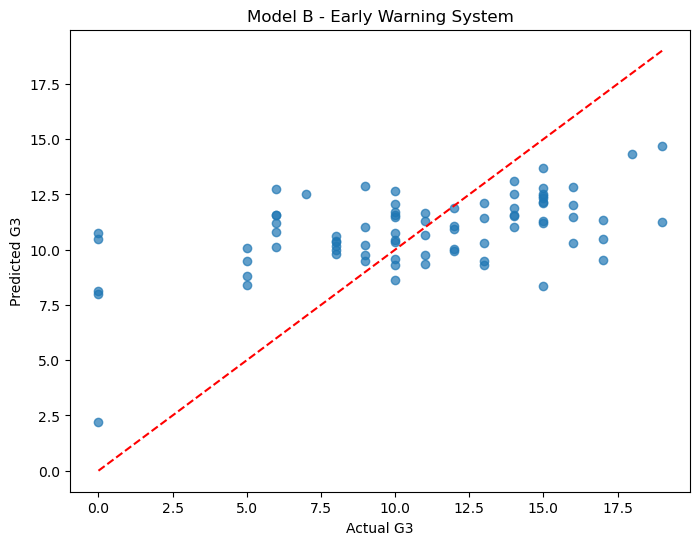

In [42]:
plt.figure(figsize=(8,6))
plt.scatter(y2_test, pred3, alpha=0.7)

min_val = min(min(y2_test), min(pred3))
max_val = max(max(y2_test), max(pred3))

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    "r--"
)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Model B - Early Warning System")
plt.show()

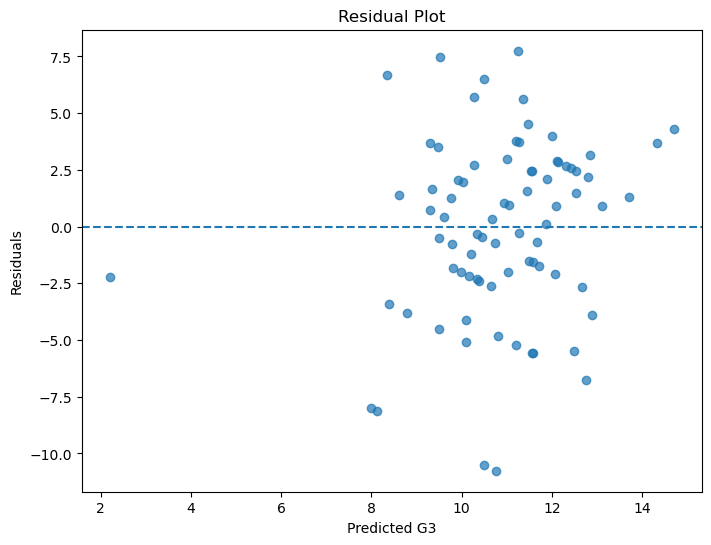

In [38]:
residuals = y2_test - pred3
plt.figure(figsize=(8,6))
plt.scatter(pred3, residuals, alpha=0.7)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted G3")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


Top 15 Important Features:
absences      0.192306
failures      0.142517
health        0.056089
goout         0.052358
age           0.042337
studytime     0.034095
freetime      0.033124
traveltime    0.031780
Fedu          0.029511
Walc          0.028824
famrel        0.025640
Medu          0.024197
schoolsup     0.023934
romantic      0.021354
higher        0.019907
dtype: float64


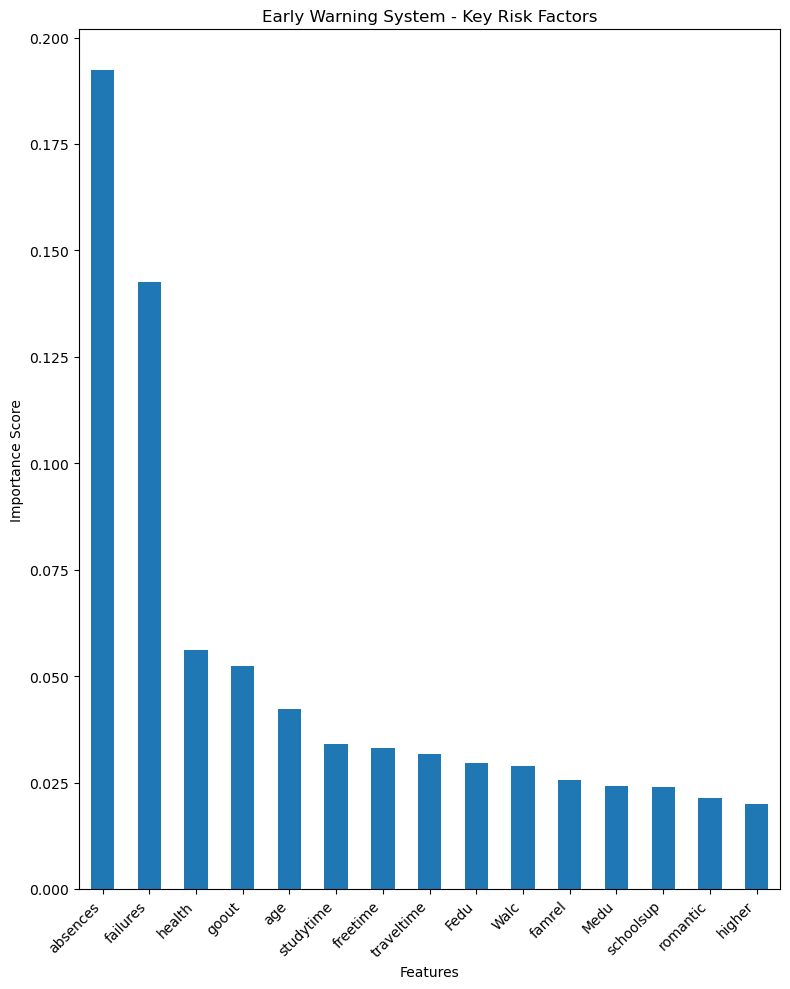

In [43]:
importance = pd.Series(model_B.feature_importances_,index=x2_train.columns).sort_values(ascending=False)

print("\nTop 15 Important Features:")
print(importance.head(15))

plt.figure(figsize=(8,10))

importance.head(15).plot(kind="bar")

plt.title("Early Warning System - Key Risk Factors")
plt.xlabel("Features")
plt.ylabel("Importance Score")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 24. Save Model B

In [40]:
os.makedirs("../model", exist_ok=True)
joblib.dump(model_A, "../model/model_B_final_grade.pkl")

['../model/model_B_final_grade.pkl']

## 25. Conclusion

#### This project successfully built two machine learning models to predict student performance and identify at-risk students.

#### Model A showed that previous grades (G1 and G2) are the strongest predictors of final performance, achieving high accuracy.

#### Model B demonstrated that even without exam scores, student outcomes can be predicted using behavioral and social factors such as study habits, absences, and family background.

#### Overall, the project highlights that while academic history is the strongest indicator of success, lifestyle and personal factors play an important role in early risk detection.

#### This system can help educational institutions move from reactive evaluation to proactive student support.